<a href="https://colab.research.google.com/github/ishikaagarwal055/Data-Science/blob/main/Car_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/ishikaagarwal055/Data-Science/main/CarPrice_Assignment.csv"
df = pd.read_csv(url)

# drop useless values
df.drop(['car_ID', 'CarName','fueltype', 'aspiration', 'doornumber', 'carbody','drivewheel','enginelocation','enginetype','cylindernumber','fuelsystem'], axis = 1, inplace = True)
# print(df)

# feature scaling
scaler = StandardScaler()
feature_columns = df.drop('price', axis = 1).columns
df[feature_columns] = scaler.fit_transform(df[feature_columns])
print(df)

# split data
x = df.drop('price', axis = 1)
y = df['price']

# train test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# model train
model = LinearRegression()
model.fit(x_train, y_train)

# prediction data
new_data = pd.DataFrame(
    {
        'symboling': [1],
        'wheelbase': [95.1],
        'carlength': [168.8],
        'carwidth': [64.1],
        'carheight': [54.1],
        'curbweight': [2548],
        'enginesize': [130],
        'boreratio': [3.47],
        'stroke': [2.68],
        'compressionratio': [9.0],
        'horsepower': [111],
        'peakrpm': [5000],
        'citympg': [21],
        'highwaympg': [27]
    }
)

# feature scaling
new_data[feature_columns] = scaler.transform(new_data[feature_columns])
print(new_data)

# prediction
predict_data = model.predict(new_data)
print(predict_data[0])

# model dumb
# !pip install joblib
import joblib
joblib.dump(model, 'car_model.joblib')












     symboling  wheelbase  carlength  carwidth  carheight  curbweight  \
0     1.743470  -1.690772  -0.426521 -0.844782  -2.020417   -0.014566   
1     1.743470  -1.690772  -0.426521 -0.844782  -2.020417   -0.014566   
2     0.133509  -0.708596  -0.231513 -0.190566  -0.543527    0.514882   
3     0.938490   0.173698   0.207256  0.136542   0.235942   -0.420797   
4     0.938490   0.107110   0.207256  0.230001   0.235942    0.516807   
..         ...        ...        ...       ...        ...         ...   
200  -1.476452   1.721873   1.198549  1.398245   0.728239    0.763241   
201  -1.476452   1.721873   1.198549  1.351515   0.728239    0.949992   
202  -1.476452   1.721873   1.198549  1.398245   0.728239    0.878757   
203  -1.476452   1.721873   1.198549  1.398245   0.728239    1.273437   
204  -1.476452   1.721873   1.198549  1.398245   0.728239    0.975021   

     enginesize  boreratio    stroke  compressionratio  horsepower   peakrpm  \
0      0.074449   0.519071 -1.839377       

['car_model.joblib']

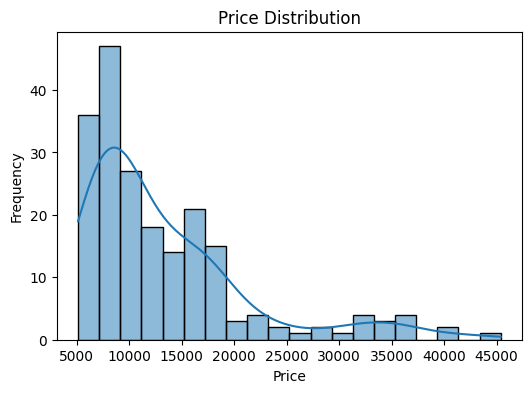

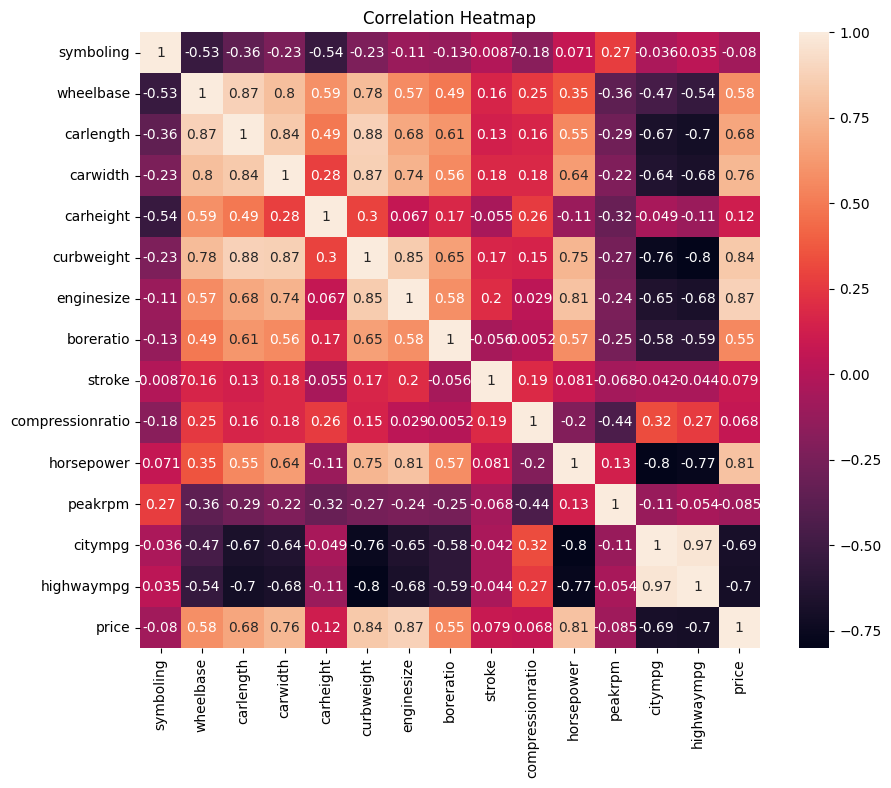

<Figure size 600x600 with 0 Axes>

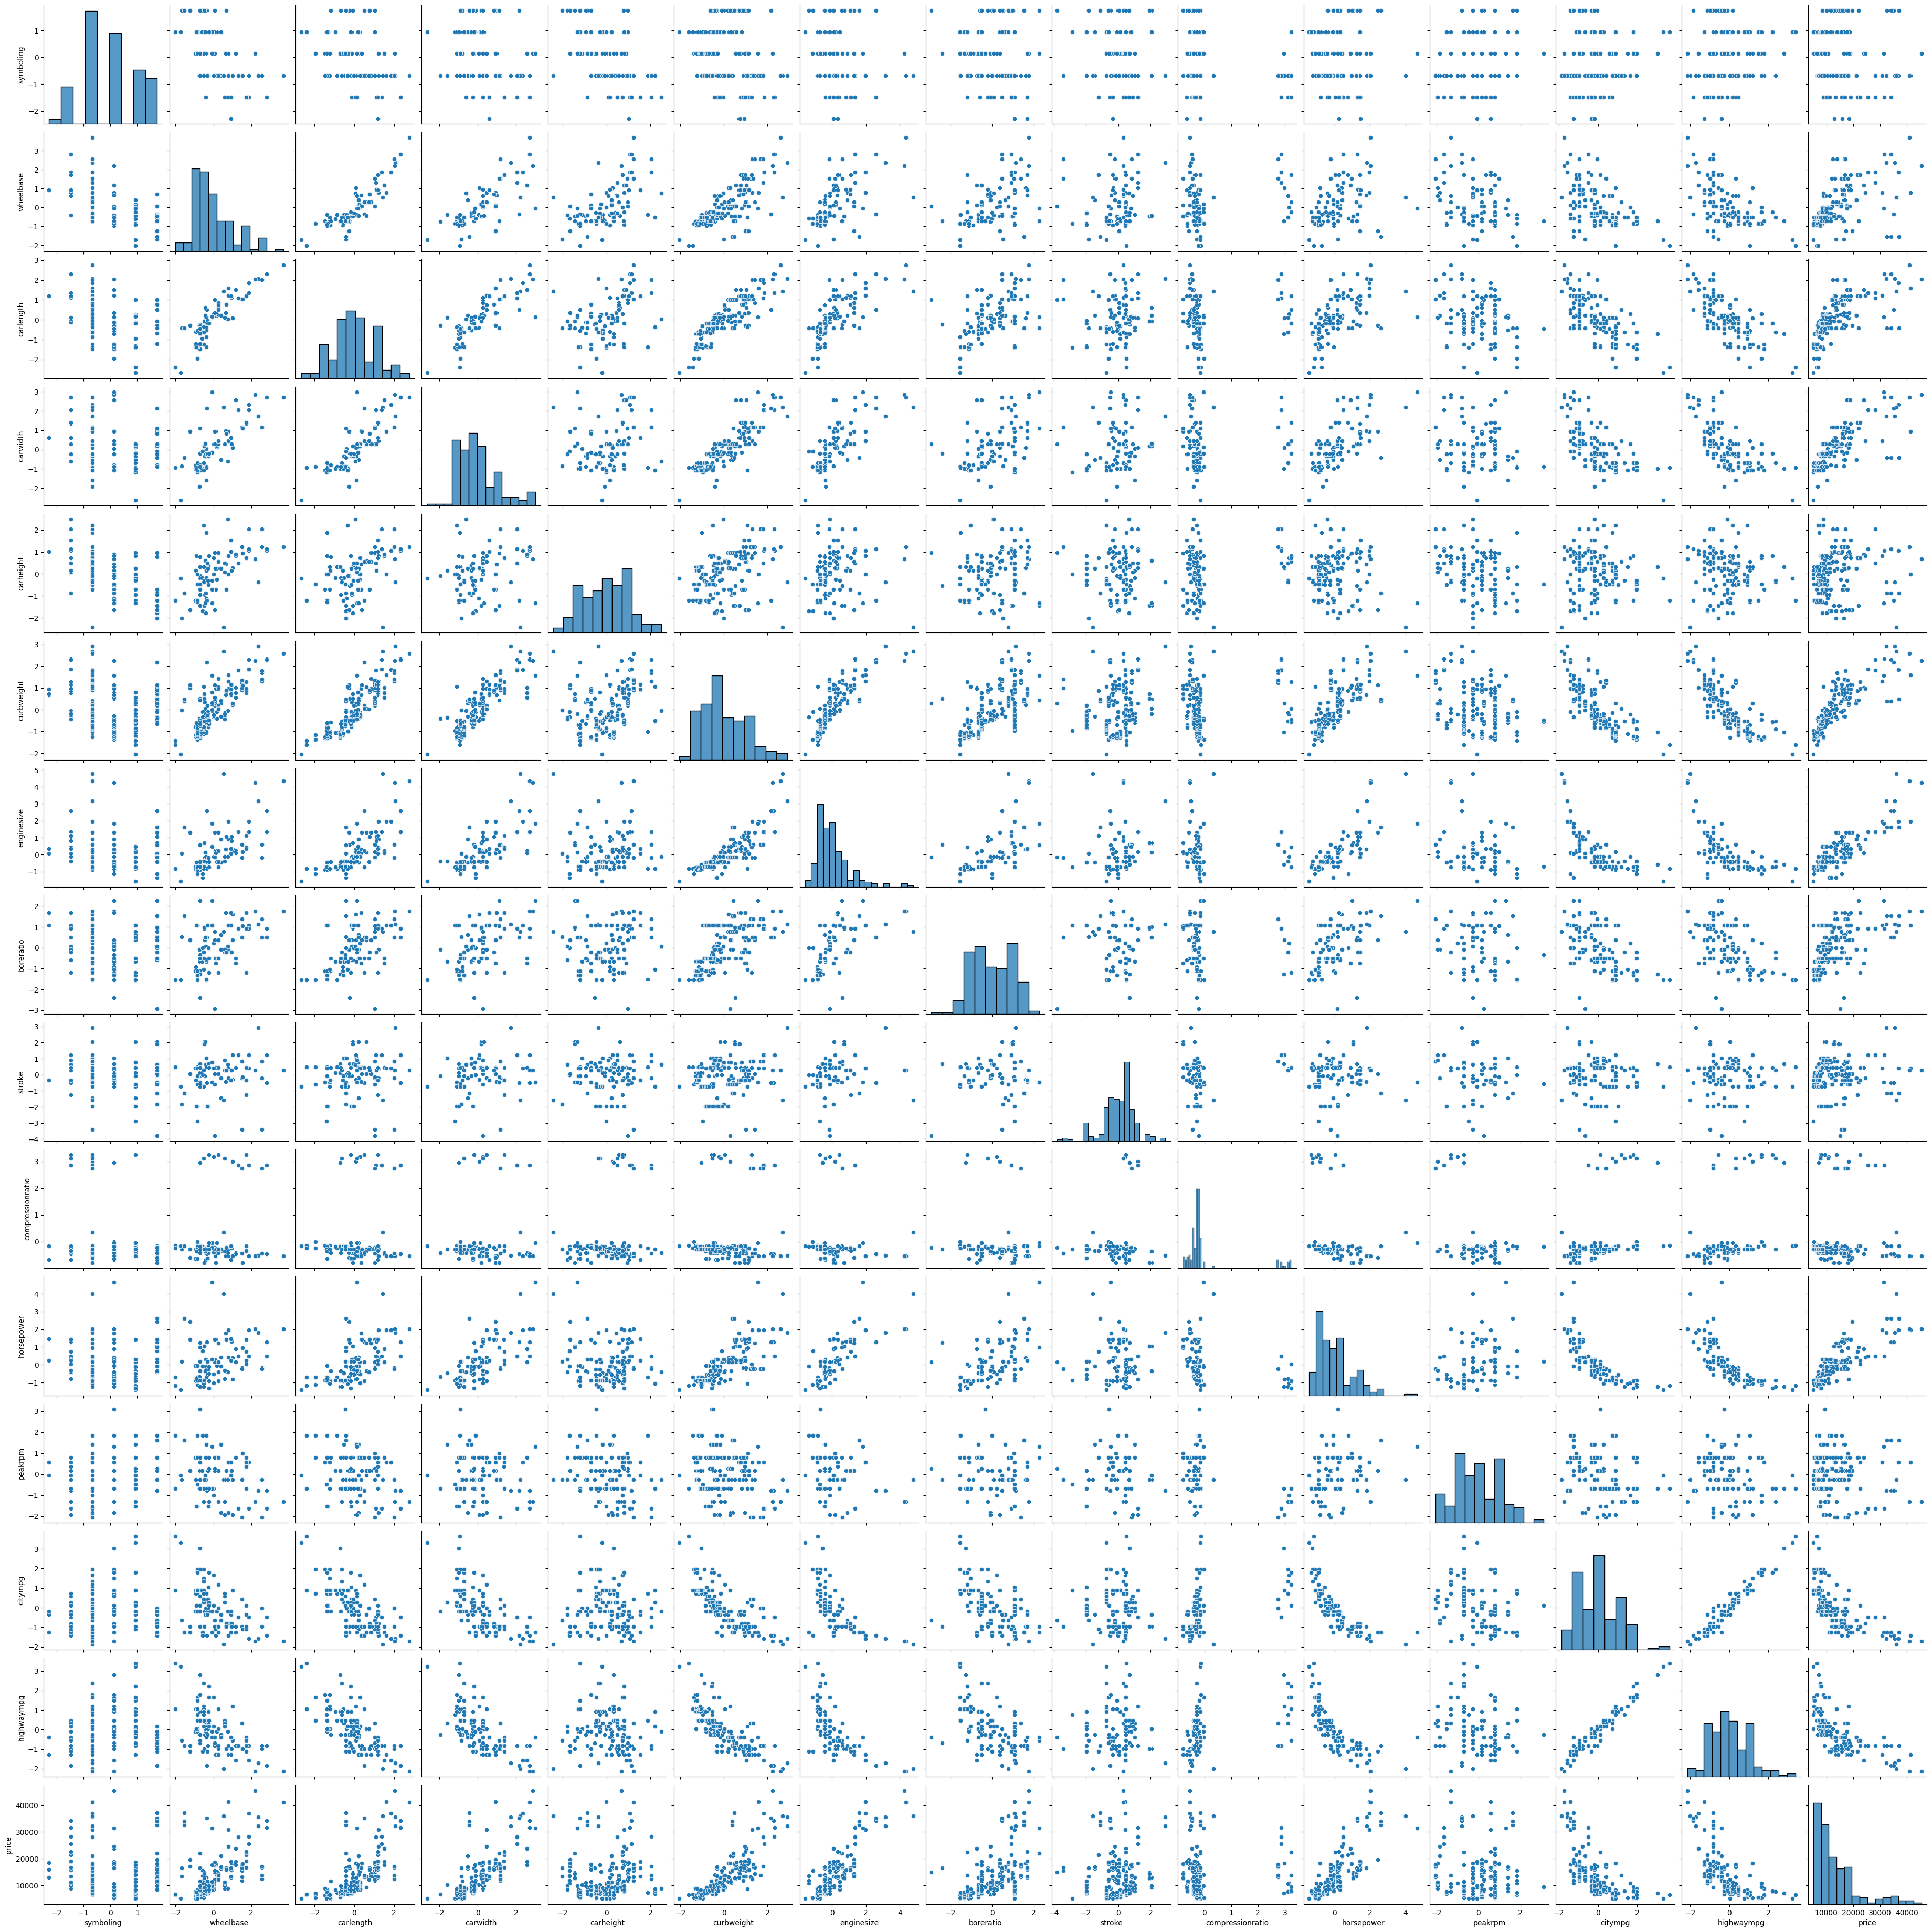

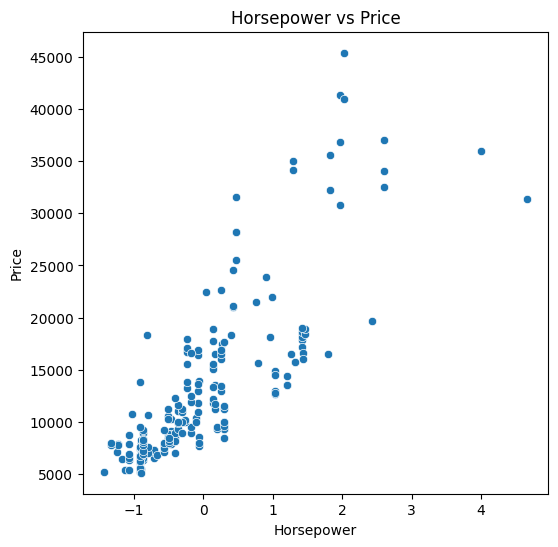

<Figure size 640x480 with 0 Axes>

In [22]:
# price distribution
plt.figure(figsize = (6,4))
sns.histplot(df['price'],bins=20,kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# corelation heatmap
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

# pairplot
plt.figure(figsize = (6,6))
sns.pairplot(df)
plt.show()

# scatter plot
plt.figure(figsize = (6,6))
sns.scatterplot(x = 'horsepower', y = 'price', data = df)
plt.title('Horsepower vs Price')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.show()

